In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
df=pd.read_csv('new.csv')
df.isnull().sum()

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [39]:
df['Income'] = df.groupby('Education')['Income'].transform(
    lambda x: x.fillna(x.median())
)
df['Income'] = np.log1p(df['Income'])
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
Total_Spending         0
dtype: int64

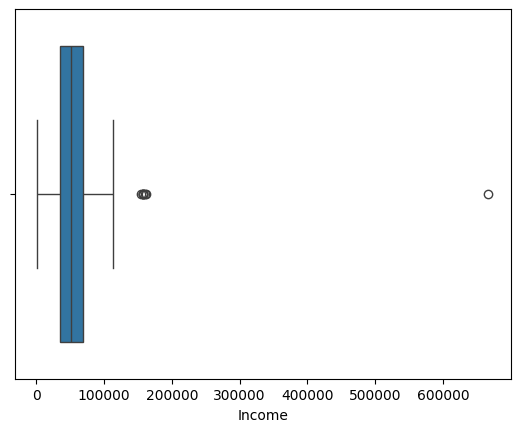

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Income'])
plt.show()

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df[['Income']]   
X_scaled = scaler.fit_transform(X)

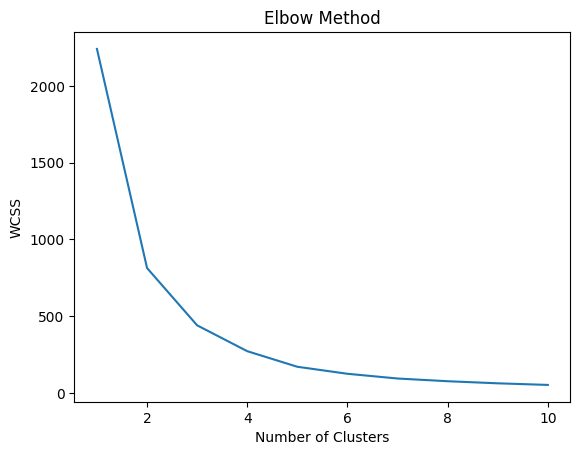

In [44]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

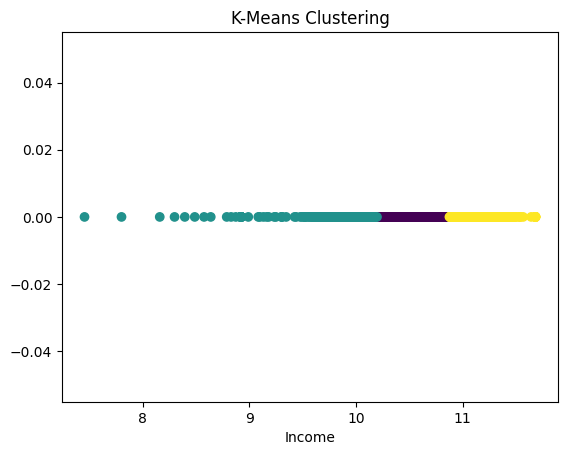

[[-0.33654984]
 [-1.83634787]
 [ 0.7819501 ]]


In [47]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
plt.scatter(df['Income'], np.zeros_like(df['Income']), c=df['Cluster'], cmap='viridis')
plt.xlabel("Income")
plt.title("K-Means Clustering")
plt.show()
print(kmeans.cluster_centers_)

In [48]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending,Cluster
0,5524,1957,Graduation,Single,10.970592,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,1617,2
1,2174,1954,Graduation,Single,10.743869,1,1,08-03-2014,38,11,...,0,0,0,0,0,3,11,0,27,0
2,4141,1965,Graduation,Together,11.179046,0,0,21-08-2013,26,426,...,0,0,0,0,0,3,11,0,776,2
3,6182,1984,Graduation,Together,10.190432,1,0,10-02-2014,26,11,...,0,0,0,0,0,3,11,0,53,1
4,5324,1981,PhD,Married,10.973254,1,0,19-01-2014,94,173,...,0,0,0,0,0,3,11,0,422,2


In [49]:
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                          'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

In [54]:
X = df[['Income', 'Total_Spending']]
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

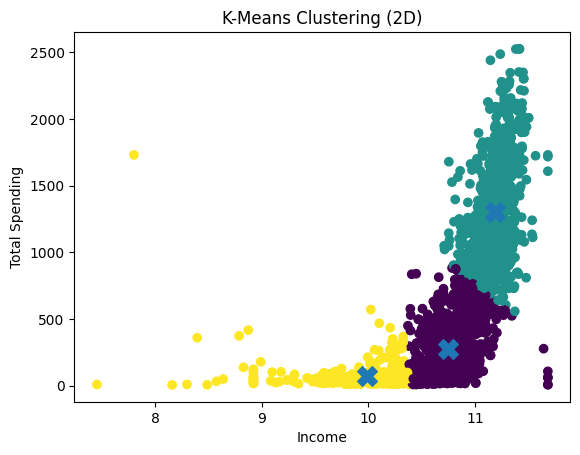

In [55]:

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(df['Income'], df['Total_Spending'], c=df['Cluster'])

plt.scatter(centers[:, 0], centers[:, 1], s=200, marker='X')

plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.title("K-Means Clustering (2D)")

plt.show()